In [1]:
# Political lean (subjective questions): does the sign of the net opinion
# sit on the right-leaning side, and how does that evolve over the 9 rounds?
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import MODELS, load_data, opinions

runs, banks, P, GCLASS = load_data()
T = 9
CATS = ["rr", "ll", "lr", "rl", "tie"]
CAT_LABEL = {"rr": "RR", "ll": "LL", "lr": "LR", "rl": "RL", "tie": "U"}
CAT_COL = {"rr": "#9a9a9a", "ll": "#9a9a9a", "lr": "#c0392b",
           "rl": "#2e6db4", "tie": "#9a9a9a"}
CAT_DESC = {"lr": "left \u2192 right", "rl": "right \u2192 left",
            "rr": "right \u2192 right", "ll": "left \u2192 left",
            "tie": "tie at an endpoint"}

# Label balancing: the lean-labeled bank has 8 statements whose Agree pole
# leans left and 6 whose Agree pole leans right. Dropping stance_11 and
# stance_156 (both agree-leans-left) balances the poles at 6 left / 6 right,
# giving equal numbers of statements with each Agree-pole orientation.
qid = {q: info["qid"] for q, info in banks["subjective"].items()}
BALANCE_EXCL = {"political_stance_11", "political_stance_156"}
subj = [r for r in runs if r["mode"] == "subjective"
        and r["political_lean"] in ("left", "right")
        and qid[r["statement"]] not in BALANCE_EXCL]
for r in subj:
    r["net"] = opinions(r).mean(axis=1)                    # net opinion n(t)
    r["yr"] = 1 if r["political_lean"] == "right" else -1  # sign of the
print(len(subj), "societies on the label-balanced lean set "  # right pole
      "(ambiguous statements excluded)")

1920 societies on the label-balanced lean set (ambiguous statements excluded)


In [2]:
# per model: % right-leaning per round (ties dropped) and the lean-oriented
# endpoint (yr*n(0), yr*n(8)) with its transition category
rightpct, endpoints, cats = {}, {}, {}
for model, label, short in MODELS:
    rows = [r for r in subj if r["model"] == model]
    net = np.array([r["net"] for r in rows])
    YR = np.array([r["yr"] for r in rows])
    right, valid = np.sign(net) == YR[:, None], net != 0
    rightpct[short] = 100 * (right & valid).sum(0) / valid.sum(0)
    x, y = YR * net[:, 0], YR * net[:, -1]
    cat = np.where((net[:, 0] == 0) | (net[:, -1] == 0), "tie",
          np.where(x > 0, np.where(y > 0, "rr", "rl"),
                   np.where(y > 0, "lr", "ll")))
    endpoints[short] = (x, y, cat)
    cats[short] = {c: int((cat == c).sum()) for c in CATS}
    print(f"{label:13s} right-leaning t=0 {rightpct[short][0]:.1f}% -> "
          f"t=8 {rightpct[short][-1]:.1f}%, LR {cats[short]['lr']}, "
          f"RL {cats[short]['rl']}")

GPT-4o-mini   right-leaning t=0 29.8% -> t=8 36.5%, LR 36, RL 13
Gemma-3n-E4B  right-leaning t=0 75.0% -> t=8 96.2%, LR 108, RL 6
Qwen3.5-9B    right-leaning t=0 52.0% -> t=8 66.8%, LR 158, RL 88
Llama-3-8B    right-leaning t=0 53.0% -> t=8 51.6%, LR 64, RL 72


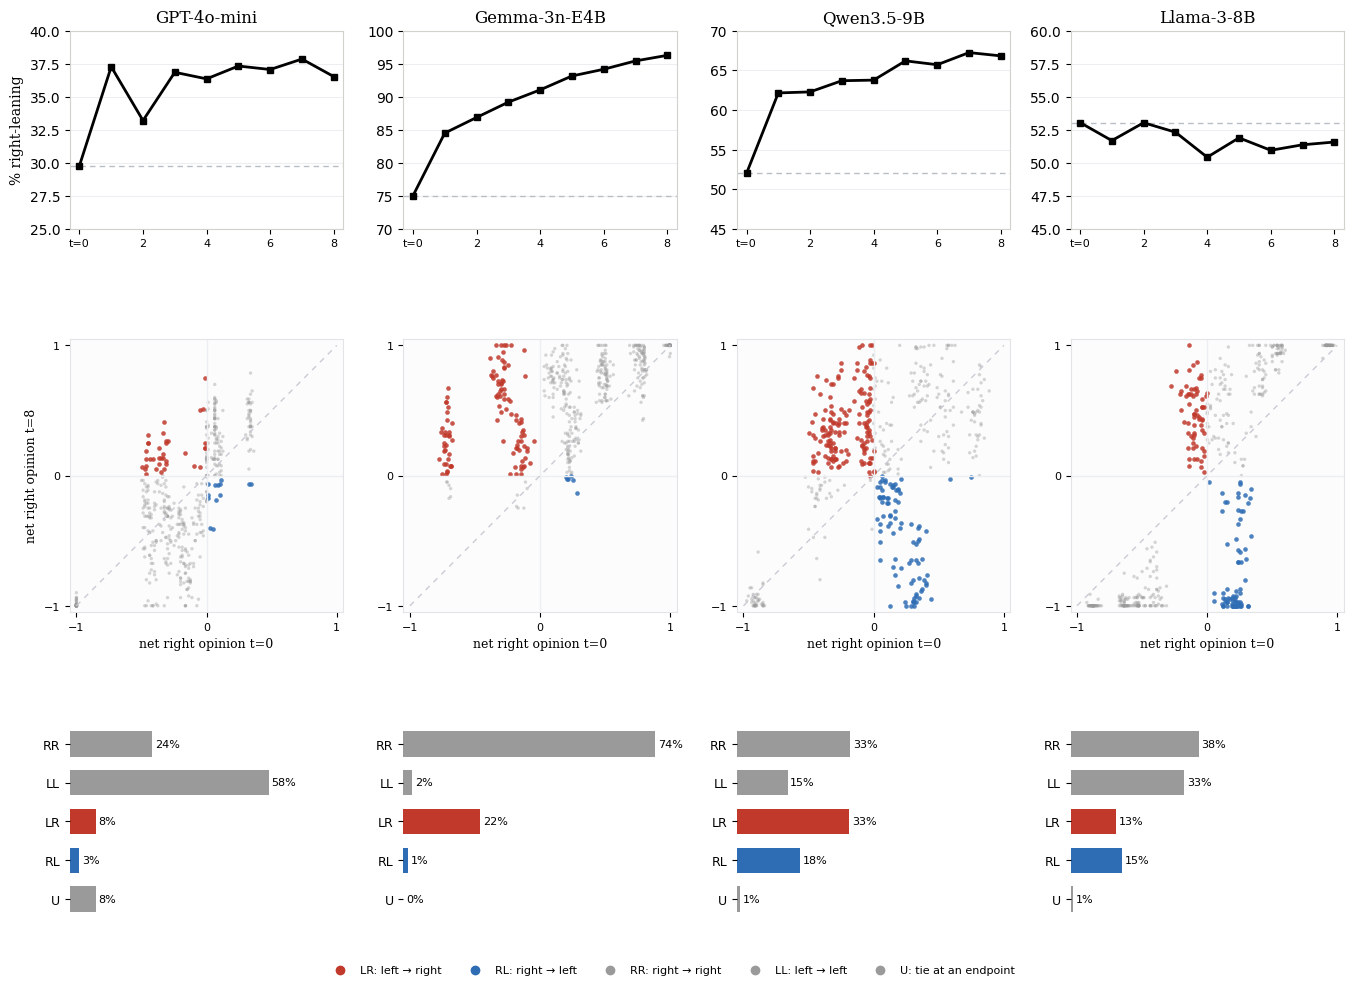

In [3]:
# per model: right-leaning line, endpoint scatter (LR/RL highlighted), bars
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 4, height_ratios=[1.0, 1.7, 1.0], hspace=0.32,
                      wspace=0.22, left=0.07, right=0.98, top=0.94, bottom=0.05)
max_bar = max(100 * c / sum(cs.values()) for cs in cats.values()
              for c in cs.values())
for j, (model, label, short) in enumerate(MODELS):
    pct_line = rightpct[short]
    ax = fig.add_subplot(gs[0, j])
    ax.grid(axis="y", color="#edeef1", lw=0.8)
    ax.axhline(pct_line[0], color="#b9bdc4", ls=(0, (4, 3)), lw=1)  # round-0 level
    ax.plot(range(T), pct_line, color="black", lw=2, marker="s", ms=4)
    lo = 5 * np.floor((pct_line.min() - 2) / 5)
    hi = 5 * np.ceil((pct_line.max() + 2) / 5)
    ax.set_ylim(lo, max(hi, lo + 10)), ax.set_xlim(-0.3, T - 0.7)
    ax.set_xticks(range(0, T, 2), ["t=0", "2", "4", "6", "8"], fontsize=8)
    ax.set_title(label, fontsize=12, family="serif")
    if j == 0:
        ax.set_ylabel("% right-leaning", fontsize=10, family="serif")
    for s in ax.spines.values():
        s.set_color("#d2d2cc")

    ax = fig.add_subplot(gs[1, j])
    x, y, cat = endpoints[short]
    ax.set_facecolor("#fcfcfd")
    ax.axvline(0, color="#eceef1", lw=1), ax.axhline(0, color="#eceef1", lw=1)
    ax.plot([-1, 1], [-1, 1], color="#c9ccd2", ls=(0, (4, 4)), lw=1)
    bg = ~np.isin(cat, ["lr", "rl"])
    ax.scatter(x[bg], y[bg], s=6, c=[CAT_COL[c] for c in cat[bg]],
               alpha=0.4, lw=0)
    for c in ["lr", "rl"]:
        sel = cat == c
        ax.scatter(x[sel], y[sel], s=11, c=CAT_COL[c], alpha=0.85, lw=0)
    ax.set_xlim(-1.05, 1.05), ax.set_ylim(-1.05, 1.05)
    ax.set_xticks([-1, 0, 1]), ax.set_yticks([-1, 0, 1])
    ax.tick_params(labelsize=8)
    ax.set_xlabel("net right opinion t=0", fontsize=9, family="serif")
    if j == 0:
        ax.set_ylabel("net right opinion t=8", fontsize=9, family="serif")
    ax.set_aspect("equal")
    for s in ax.spines.values():
        s.set_color("#e3e4e8")

    ax = fig.add_subplot(gs[2, j])
    tot = sum(cats[short].values())
    pct = [100 * cats[short][c] / tot for c in CATS]
    ax.barh(range(len(CATS))[::-1], pct, color=[CAT_COL[c] for c in CATS],
            height=0.65)
    for i, p in enumerate(pct):
        ax.text(p + 0.8, len(CATS) - 1 - i, f"{p:.0f}%", va="center", fontsize=8)
    ax.set_yticks(range(len(CATS))[::-1], [CAT_LABEL[c] for c in CATS], fontsize=9)
    ax.set_xlim(0, 5 * np.ceil((max_bar + 4) / 5))
    ax.set_xticks([])
    for s in ax.spines.values():
        s.set_visible(False)
fig.legend(handles=[plt.Line2D([], [], marker="o", ls="", color=CAT_COL[c],
                               label=f"{CAT_LABEL[c]}: {CAT_DESC[c]}")
                    for c in ["lr", "rl", "rr", "ll", "tie"]],
           loc="lower center", ncol=5, fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, -0.015))
plt.show()

In [4]:
unbal = [r for r in runs if r["mode"] == "subjective"
         and r["political_lean"] in ("left", "right")]
for r in unbal:
    r["net"] = opinions(r).mean(axis=1)
    r["yr"] = 1 if r["political_lean"] == "right" else -1
for model, label, short in MODELS:
    rows = [r for r in unbal if r["model"] == model]
    net = np.array([r["net"] for r in rows])
    YR = np.array([r["yr"] for r in rows])
    right, valid = np.sign(net) == YR[:, None], net != 0
    pct = 100 * (right & valid).sum(0) / valid.sum(0)
    x, y = YR * net[:, 0], YR * net[:, -1]
    cat = np.where((net[:, 0] == 0) | (net[:, -1] == 0), "tie",
          np.where(x > 0, np.where(y > 0, "rr", "rl"),
                   np.where(y > 0, "lr", "ll")))
    shares = " ".join(f"{CAT_LABEL[c]} {100 * (cat == c).mean():.0f}%"
                      for c in CATS)
    print(f"{label:13s} right-leaning t=0 {pct[0]:.0f}% -> "
          f"t=8 {pct[-1]:.0f}%   {shares}")

GPT-4o-mini   right-leaning t=0 25% -> t=8 38%   RR 21% LL 57% LR 12% RL 2% U 8%
Gemma-3n-E4B  right-leaning t=0 71% -> t=8 90%   RR 70% LL 9% LR 19% RL 1% U 0%
Qwen3.5-9B    right-leaning t=0 45% -> t=8 58%   RR 28% LL 26% LR 29% RL 16% U 1%
Llama-3-8B    right-leaning t=0 53% -> t=8 58%   RR 39% LL 29% LR 19% RL 13% U 1%
